<a href="https://colab.research.google.com/github/gabis0604/projetos-da-faculdade-linguagem-de-sistemas/blob/main/unidade_3_aula_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Aula 5 unidade 3

In [5]:
import sqlite3

conn = sqlite3.connect('minhaloja.db')

cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS vendas (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    data TEXT,
    produto TEXT,
    categoria TEXT,
    quantidade INTEGER,
    valor_unitario REAL)
    """)
cursor.execute("DELETE FROM vendas")
conn.commit()
print("Banco da MinhaLoja pronto.")

Banco da MinhaLoja pronto.


In [6]:

vendas_exemplo = [
    ('2024-01-15', 'Notebook',       'Informática',      1, 3500.00),
    ('2024-01-20', 'Cafeteira',      'Eletrodoméstico',  2, 350.00),
    ('2024-01-30', 'Fone Bluetooth', 'Acessório',        4, 180.00),
    ('2024-02-05', 'Smartphone',     'Informática',      1, 2200.00),
    ('2024-02-18', 'Fone Bluetooth', 'Acessório',        3, 180.00),
    ('2024-02-25', 'Notebook',       'Informática',      2, 3500.00),
    ('2024-03-10', 'Geladeira',      'Eletrodoméstico',  1, 2900.00),
    ('2024-03-22', 'Fone Bluetooth', 'Acessório',        5, 180.00),
    ('2024-03-28', 'Cafeteira',      'Eletrodoméstico',  1, 350.00),
    ('2024-04-02', 'Smartphone',     'Informática',      2, 2200.00),
    ('2024-04-19', 'Geladeira',      'Eletrodoméstico',  1, 2900.00),
    ('2024-04-25', 'Notebook',       'Informática',      1, 3500.00),
    ('2024-05-03', 'Cafeteira',      'Eletrodoméstico',  3, 350.00),
    ('2024-05-15', 'Smartphone',     'Informática',      2, 2200.00),
    ('2024-05-28', 'Fone Bluetooth', 'Acessório',        6, 180.00),
    ('2024-06-10', 'Geladeira',      'Eletrodoméstico',  2, 2900.00),
    ('2024-06-20', 'Notebook',       'Informática',      3, 3500.00),
    ('2024-06-30', 'Smartphone',     'Informática',      1, 2200.00),
]
cursor.executemany("INSERT INTO vendas (data, produto, categoria, quantidade, valor_unitario) VALUES (?, ?, ?, ?, ?)", vendas_exemplo)
conn.commit()
print(f"{len(vendas_exemplo)} vendas inseridas")

18 vendas inseridas


In [7]:
import pandas as pd

df = pd.read_sql("SELECT * FROM vendas", conn)
conn.close()

df['total'] = df['quantidade'] * df['valor_unitario']
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.month
df['mes_nome'] = df['data'].dt.strftime('%b')

print(f"Faturamento total da MinhaLoja: R$ {df['total'].sum():,.2f}")
df.head()

Faturamento total da MinhaLoja: R$ 54,640.00


,id,data,produto,categoria,quantidade,valor_unitario,total,mes,mes_nome
0,1,2024-01-15,Notebook,Informática,1,3500.0,3500.0,1,Jan
1,2,2024-01-20,Cafeteira,Eletrodoméstico,2,350.0,700.0,1,Jan
2,3,2024-01-30,Fone Bluetooth,Acessório,4,180.0,720.0,1,Jan
3,4,2024-02-05,Smartphone,Informática,1,2200.0,2200.0,2,Feb
4,5,2024-02-18,Fone Bluetooth,Acessório,3,180.0,540.0,2,Feb


In [8]:
acima_media = df[df['total'] > df['total'].mean()]
print(f"Faturamento acima da média: R$ {acima_media['total'].sum():,.2f}")


Faturamento acima da média: R$ 39,100.00


In [9]:
# 4. Filtro booleano – destaque pro produto mais vendido em valor
acima_de_1000 = df[df['total'] > 1000]

print(f"Vendas acima de R$1.000: {len(acima_de_1000)} de {len(df)} registros\n")

print(acima_de_1000[['data', 'produto', 'quantidade', 'total']]
      .sort_values('total', ascending=False)
      .to_string(index=False))

Vendas acima de R$1.000: 13 de 18 registros

      data        produto  quantidade   total
2024-06-20       Notebook           3 10500.0
2024-02-25       Notebook           2  7000.0
2024-06-10      Geladeira           2  5800.0
2024-04-02     Smartphone           2  4400.0
2024-05-15     Smartphone           2  4400.0
2024-01-15       Notebook           1  3500.0
2024-04-25       Notebook           1  3500.0
2024-04-19      Geladeira           1  2900.0
2024-03-10      Geladeira           1  2900.0
2024-02-05     Smartphone           1  2200.0
2024-06-30     Smartphone           1  2200.0
2024-05-28 Fone Bluetooth           6  1080.0
2024-05-03      Cafeteira           3  1050.0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_1609/1758917945.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=qtd_prod.index, y=qtd_prod.values,


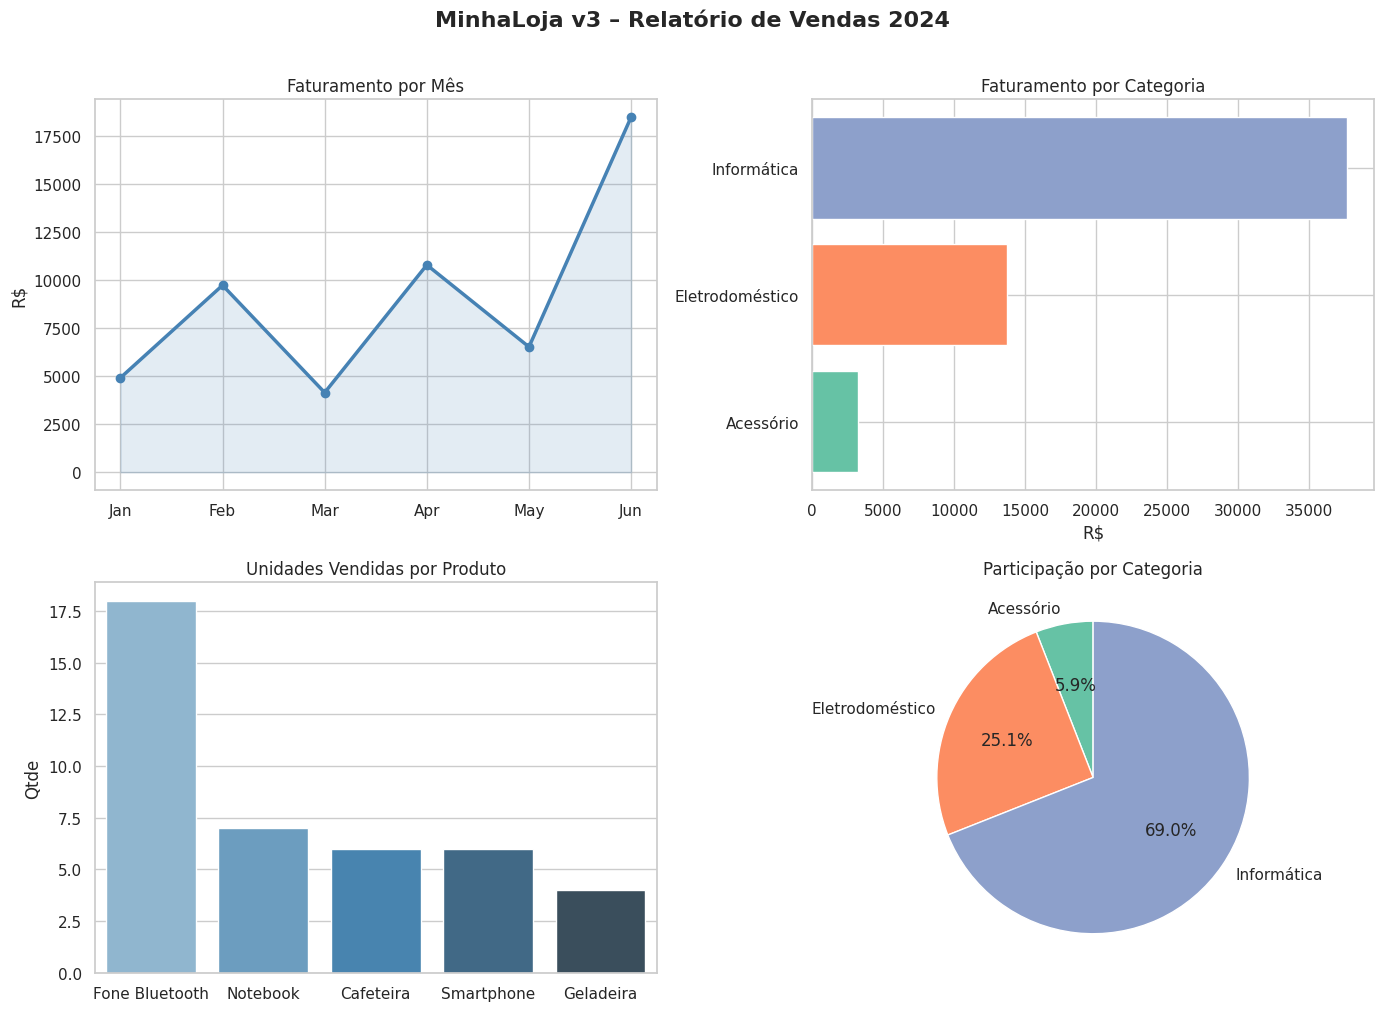

In [11]:
sns.set(style="whitegrid")
meses_ordem = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MinhaLoja v3 – Relatório de Vendas 2024',
             fontsize=16, fontweight='bold', y=1.01)

fat_mes = df.groupby('mes_nome')['total'].sum().reindex(meses_ordem)
axes[0, 0].plot(fat_mes.index, fat_mes.values,
                marker='o', color='steelblue', linewidth=2.5)
axes[0, 0].fill_between(fat_mes.index, fat_mes.values,
                        alpha=0.15, color='steelblue')
axes[0, 0].set_title('Faturamento por Mês')
axes[0, 0].set_ylabel('R$')


fat_cat = df.groupby('categoria')['total'].sum().sort_values()
axes[0, 1].barh(fat_cat.index, fat_cat.values,
                color=sns.color_palette('Set2', len(fat_cat)))
axes[0, 1].set_title('Faturamento por Categoria')
axes[0, 1].set_xlabel('R$')

qtd_prod = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False)
sns.barplot(x=qtd_prod.index, y=qtd_prod.values,
            ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('Unidades Vendidas por Produto')
axes[1, 0].set_ylabel('Qtde')
axes[1, 0].set_xlabel('')


fat_cat2 = df.groupby('categoria')['total'].sum()
axes[1, 1].pie(
    fat_cat2.values,
    labels=fat_cat2.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(fat_cat2)),
    startangle=90
)
axes[1, 1].set_title('Participação por Categoria')

plt.tight_layout()
plt.show()

In [12]:
# 6. Insight final – qual produto trouxe mais dinheiro?
ranking = (df.groupby('produto')['total']
           .sum()
           .sort_values(ascending=False)
           .reset_index())

ranking.columns = ['Produto', 'Faturamento Total']
ranking['Faturamento Total'] = ranking['Faturamento Total'].apply(
    lambda x: f"R$ {x:,.2f}"
)

print("\n🏆 Ranking de faturamento da MinhaLoja:")
print(ranking.to_string(index=False))


🏆 Ranking de faturamento da MinhaLoja:
       Produto Faturamento Total
      Notebook      R$ 24,500.00
    Smartphone      R$ 13,200.00
     Geladeira      R$ 11,600.00
Fone Bluetooth       R$ 3,240.00
     Cafeteira       R$ 2,100.00


In [14]:
conn = sqlite3.connect('minhaloja.db')
cursor = conn.cursor()

fat_mes = pd.read_sql("""
    SELECT
        strftime('%m', data) AS mes_num,
        CASE strftime('%m', data)
            WHEN '01' THEN 'Jan'
            WHEN '02' THEN 'Fev'
            WHEN '03' THEN 'Mar'
            WHEN '04' THEN 'Abr'
            WHEN '05' THEN 'Mai'
            WHEN '06' THEN 'Jun'
            WHEN '07' THEN 'Jul'
            WHEN '08' THEN 'Ago'
            WHEN '09' THEN 'Set'
            WHEN '10' THEN 'Out'
            WHEN '11' THEN 'Nov'
            WHEN '12' THEN 'Dez'
        END AS mes,
        SUM(quantidade * valor_unitario) AS faturamento
    FROM vendas
    GROUP BY mes_num
    ORDER BY mes_num
""", conn)

print("Faturamento por mês:")
print(fat_mes)

Faturamento por mês:
  mes_num  mes  faturamento
0      01  Jan       4920.0
1      02  Fev       9740.0
2      03  Mar       4150.0
3      04  Abr      10800.0
4      05  Mai       6530.0
5      06  Jun      18500.0
